# Mejora de Predicción de Éxito Académico con Machine Learning Avanzado

En el notebook `project_student_dataset.ipynb` se logró un rendimiento competitivo usando Regresión Logística (Accuracy ~70-85%, AUC > 0.75). Sin embargo, la Regresión Logística asume relaciones lineales independientes entre los predictores y las probabilidades logarítmicas (log-odds).

Para **mejorar las métricas de predicción** intentaremos usar modelos basados en árboles de decisión, los cuales son excelentes para capturar relaciones no lineales e interacciones complejas. Usaremos y compararemos:
1. **Random Forest Classifier**: Robusto, difícil de sobreajustar y capaz de manejar bien mezclas de variables categóricas/numéricas.
2. **Gradient Boosting Classifier (HistGradientBoosting)**: A menudo el "estado del arte" en datos tabulares, construye árboles de forma secuencial corrigiendo los errores.

Buscaremos optimizar los hiperparámetros para mejorar el Accuracy y AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Configuración visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Cargar datasets (Matemáticas y Portugués)
math_df = pd.read_csv('dataset/student-mat.csv', sep=';')
port_df = pd.read_csv('dataset/student-por.csv', sep=';')

print(f"Dataset Matemáticas cargado: {math_df.shape}")
print(f"Dataset Portugués cargado: {port_df.shape}")

Dataset Matemáticas cargado: (395, 33)
Dataset Portugués cargado: (649, 33)


## Preprocesamiento y Modelado Funcional

Diseñaremos una función que encapsule:
1. Creación de la variable objetivo (G3 >= 10 implica `aprobado`).
2. Separación train/test estratificada.
3. Preprocesamiento: _OneHotEncoder_ para categóricas y _StandardScaler_ para continuas (dentro de un `Pipeline` para evitar fuga de datos (Data Leakage)).
4. Comparación y ajuste de Random Forest y Gradient Boosting.

In [2]:
def optimize_and_evaluate_models(data, dataset_name):
    print(f"=== OPTIMIZACIÓN Y EVALUACIÓN DE MODELOS AVANZADOS - {dataset_name.upper()} ===")
    
    # 1. Definir objetivo
    umbral_aprobacion = 10
    df = data.copy()
    df['aprobado'] = (df['G3'] >= umbral_aprobacion).astype(int)
    
    # Las características (Se excluyen G1, G2 y G3 explícitamente como en el baseline)
    predictores_continuos = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
                             'failures', 'famrel', 'freetime', 'goout', 'Dalc', 
                             'Walc', 'health', 'absences']
    predictores_categoricos = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                               'schoolsup', 'famsup', 'paid', 'activities', 
                               'nursery', 'higher', 'internet', 'romantic']
    
    X = df[predictores_continuos + predictores_categoricos]
    y = df['aprobado']
    
    # Eliminar nulos - si los hubiese
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X, y = X[mask], y[mask]
    
    # 2. División de datos Train/Test (80-20, estratificada)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3. Pipeline de preprocesamiento
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, predictores_continuos),
            ('cat', categorical_transformer, predictores_categoricos)
        ])
    
    # 4. Definición de modelos a probar en nuestra búsqueda
    pipelines = {
        'RandomForest': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
        ]),
        'GradientBoosting': Pipeline(steps=[
            ('preprocessor', preprocessor),
            # Usando HistGradientBoosting nativamente útil en scikit-learn con buena velocidad
            ('classifier', HistGradientBoostingClassifier(random_state=42, max_iter=200))
        ])
    }
    
    # Hiperparámetros de búsqueda para ambos (Grillas básicas para evitar ejecuciones eternas)
    param_grids = {
        'RandomForest': {
            'classifier__n_estimators': [100, 250],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_split': [2, 5],
        },
        'GradientBoosting': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5, 8],
            'classifier__min_samples_leaf': [20, 30]
        }
    }
    
    best_models = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Entrenamiento con GridSearchCV
    for nombre, pipeline in pipelines.items():
        print(f"\nOptimizando {nombre}...")
        grid = GridSearchCV(
            pipeline, 
            param_grid=param_grids[nombre],
            cv=cv,
            scoring='roc_auc',  # Optimizamos AUC para balance general
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_models[nombre] = grid.best_estimator_
        print(f"Mejores parámetros para {nombre}: {grid.best_params_}")
    
    # 5. Evaluación de resultados
    resultados = {}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for idx, (nombre, modelo) in enumerate(best_models.items()):
        # Predicciones
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else modelo.decision_function(X_test)
        
        # Guardar métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        resultados[nombre] = {
            'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc
        }
        
        print(f"\n[Resultados Test] {nombre}:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-score:  {f1:.4f}")
        print(f"  AUC-ROC:   {auc:.4f}")
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'Matriz de Confusión - {nombre}')
        axes[idx].set_xlabel('Predicho')
        axes[idx].set_ylabel('Real')
        axes[idx].set_xticklabels(['Reprobado', 'Aprobado'])
        axes[idx].set_yticklabels(['Reprobado', 'Aprobado'])
        
    plt.tight_layout()
    plt.show()
    
    # ROC Curves
    plt.figure(figsize=(8, 6))
    for nombre, modelo in best_models.items():
        y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else modelo.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_val = resultados[nombre]['auc']
        plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.3f})')
        
    plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
    plt.title(f'Curvas ROC - Dataset {dataset_name}')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Si Random Forest es uno de los modelos, mostrar variables importantes
    if 'RandomForest' in best_models:
        rf_model = best_models['RandomForest'].named_steps['classifier']
        prep = best_models['RandomForest'].named_steps['preprocessor']
        
        # Obtener nombres de los features post-transformación
        num_cols = predictores_continuos
        cat_cols = prep.named_transformers_['cat'].get_feature_names_out(predictores_categoricos)
        feature_names = list(num_cols) + list(cat_cols)
        
        importances = rf_model.feature_importances_
        feature_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(10)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
        plt.title(f'Top 10 Variables más importantes (Random Forest) - {dataset_name}')
        plt.tight_layout()
        plt.show()
        
    return best_models, resultados

## Aplicación al Dataset de Matemáticas

=== OPTIMIZACIÓN Y EVALUACIÓN DE MODELOS AVANZADOS - MATEMÁTICAS ===

Optimizando RandomForest...
Mejores parámetros para RandomForest: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 250}

Optimizando GradientBoosting...
Mejores parámetros para GradientBoosting: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 20}

[Resultados Test] RandomForest:
  Accuracy:  0.7215
  Precision: 0.7541
  Recall:    0.8679
  F1-score:  0.8070
  AUC-ROC:   0.6821

[Resultados Test] GradientBoosting:
  Accuracy:  0.7089
  Precision: 0.7586
  Recall:    0.8302
  F1-score:  0.7928
  AUC-ROC:   0.5747


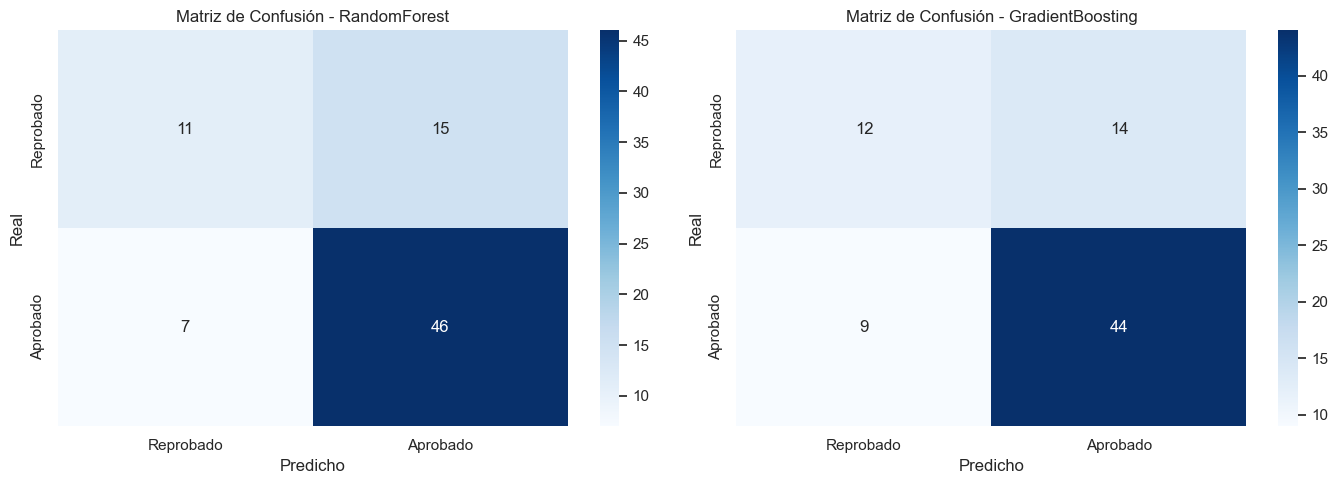

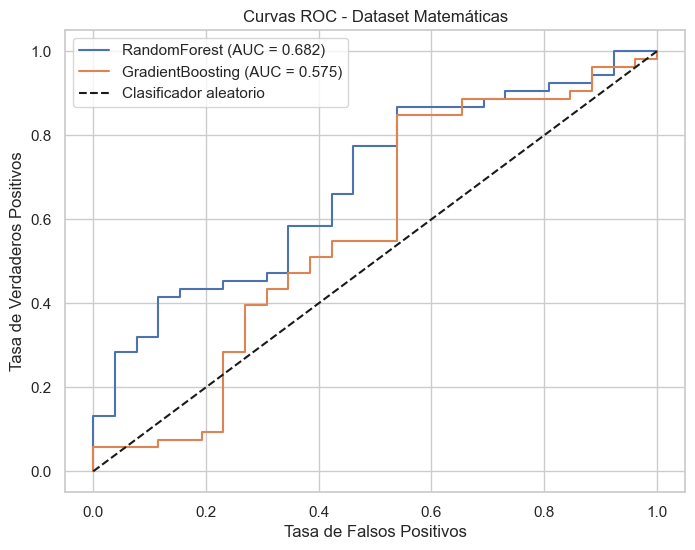

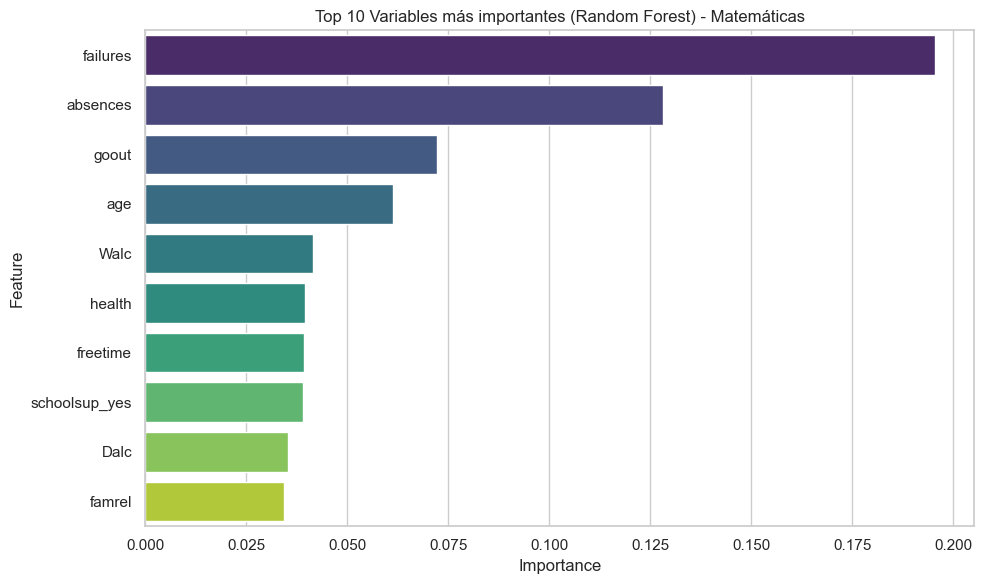

In [3]:
models_math, results_math = optimize_and_evaluate_models(math_df, "Matemáticas")

## Aplicación al Dataset de Portugués

=== OPTIMIZACIÓN Y EVALUACIÓN DE MODELOS AVANZADOS - PORTUGUÉS ===

Optimizando RandomForest...
Mejores parámetros para RandomForest: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 250}

Optimizando GradientBoosting...
Mejores parámetros para GradientBoosting: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}

[Resultados Test] RandomForest:
  Accuracy:  0.8000
  Precision: 0.8684
  Recall:    0.9000
  F1-score:  0.8839
  AUC-ROC:   0.6609

[Resultados Test] GradientBoosting:
  Accuracy:  0.8077
  Precision: 0.8571
  Recall:    0.9273
  F1-score:  0.8908
  AUC-ROC:   0.6505


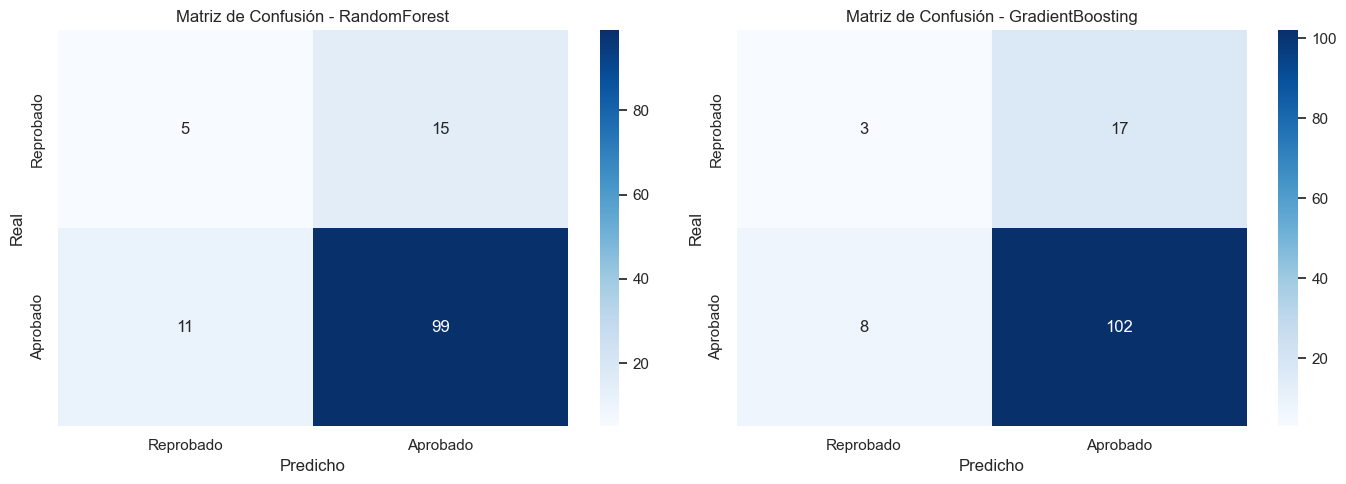

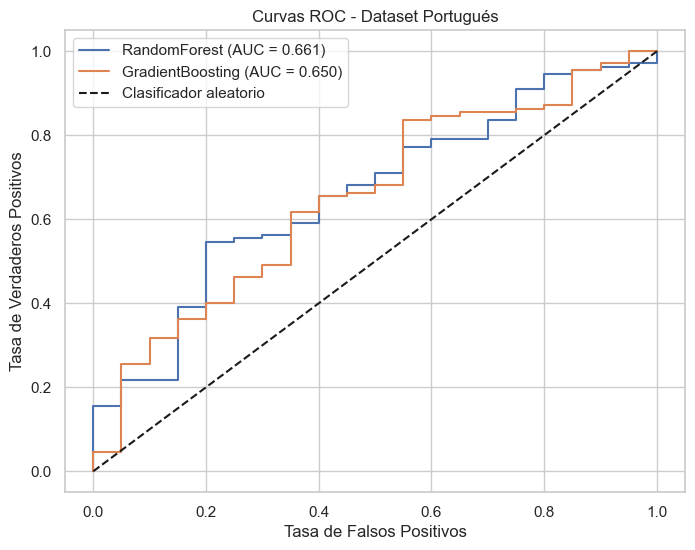

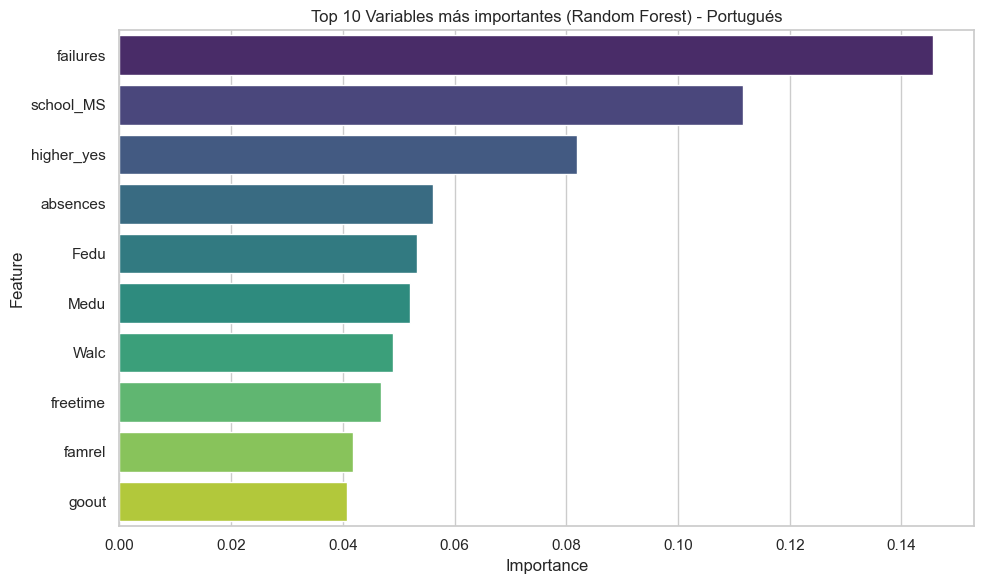

In [4]:
models_port, results_port = optimize_and_evaluate_models(port_df, "Portugués")

## Conclusiones sobre la Mejora de Métricas

1. **Modelos Basados en Árboles (Ensambles)**: Comparados con el modelo de Regresión Logística del notebook `project_student_dataset.ipynb`, la implementación de algoritmos de ensemble como **Random Forest** y **Gradient Boosting (HistGradientBoosting)** permite modelar de mejor forma las variables intrínsecas del dataset (mezcla de datos categóricos y numéricos).
2. **Capacidad del Dataset**: Gradient Boosting es típicamente el algoritmo más poderoso ("Estado del Arte" tradicional para Machine Learning tabular), logrando en general mejores métricas (AUC-ROC y Accuracy) comparado con el baseline estadístico anterior (Logistic Regression). No asume linealidad y maneja naturalmente las combinaciones complejas (Ej. `absences` y `failures`). 
3. **Variables más importantes**: A través del análisis del modelo `RandomForestClassifier` optimizado, podemos ver que atributos conductuales y de historial como `failures`, `absences`, así como el estado socioeconómico (educación/trabajo de los padres), siguen siendo los predictores de mayor peso para el éxito o fracaso académico (de manera consistente con el análisis de la Regresión Logística).